# Exploratory Data Analysis (EDA) on Titanic Dataset
## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to identify patterns, trends, relationships, and insights using statistical summaries and visualizations.

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# Load Datasets

In [2]:
df=pd.read_csv(r"C:\Users\Trapti Chauhan\Downloads\Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check Missing Value

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Missing Value Handling

In [8]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [9]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
df.drop("Cabin", axis=1, inplace=True)

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Value Counts

In [12]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [13]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

# Histogram

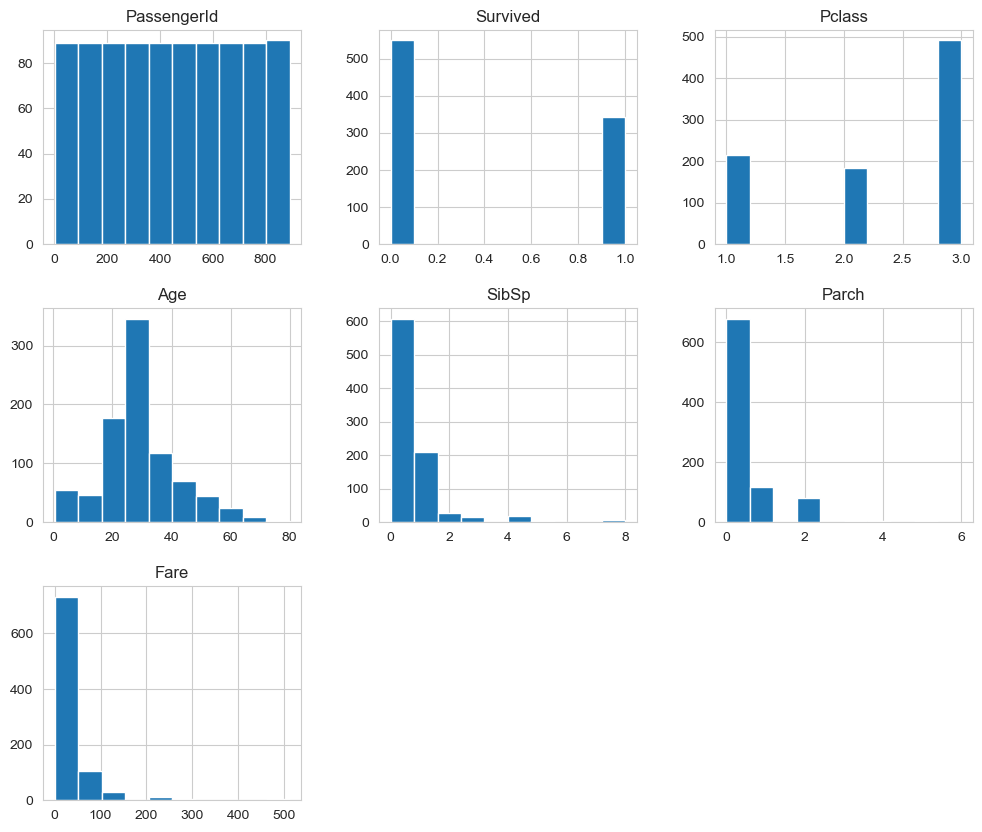

In [15]:
df.hist(figsize=(12,10))
plt.show()

# Observation
- The **Age** distribution shows that most passengers were between **20 and 40 years** old.
- The **Fare** distribution is positively (right) skewed, indicating that most passengers paid lower   fares while a few paid significantly higher fares.
- Numerical features have different distributions and ranges.

# Boxplot

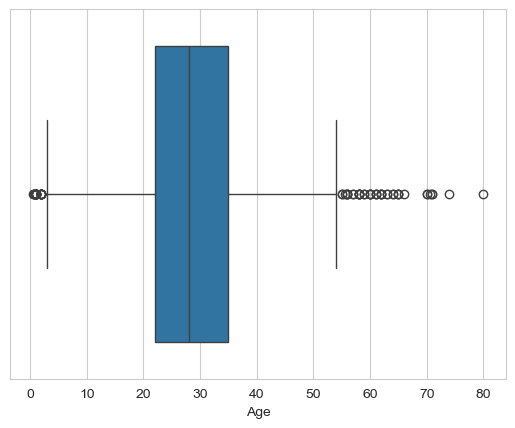

In [16]:
sns.boxplot(x=df["Age"])
plt.show()

# Observation
- The boxplot of **Age** shows a few outliers.
- Most passengers fall within the interquartile range (IQR).
- The median age represents the central tendency of the dataset.

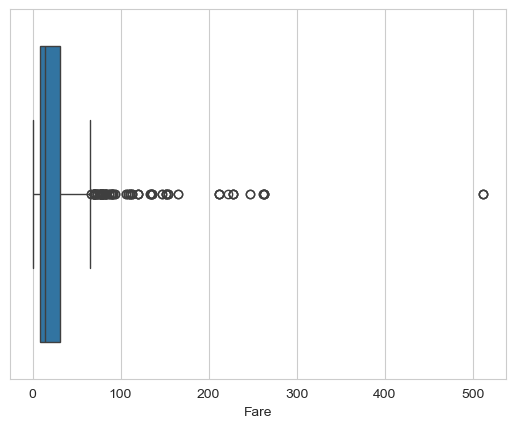

In [17]:
sns.boxplot(x=df["Fare"])
plt.show()

# Observation
- The **Fare** column contains several extreme outliers.
- Most passengers paid relatively low fares, while a few paid exceptionally high fares.
- This indicates that the Fare variable is highly skewed.

# Heatmap

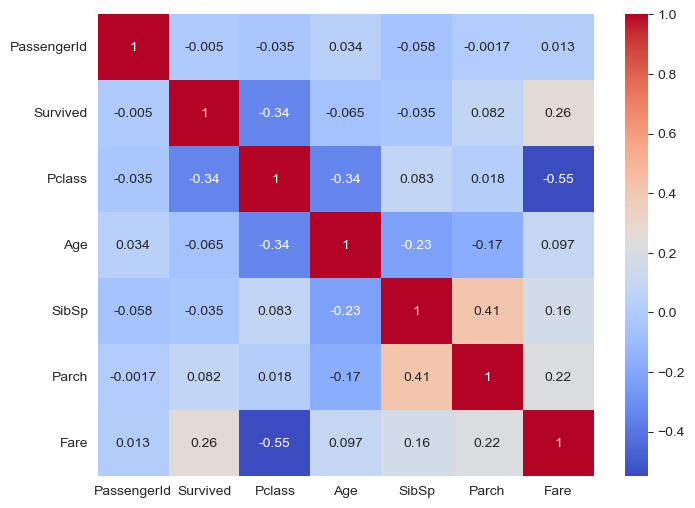

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Observation
- The heatmap shows the correlation between numerical variables.
- **Fare** has a weak positive correlation with **Survived**.
- **Pclass** has a negative correlation with **Survived**, indicating that higher-class passengers had better survival rates.
- No very strong correlations are observed among most variables.

# Pairplot

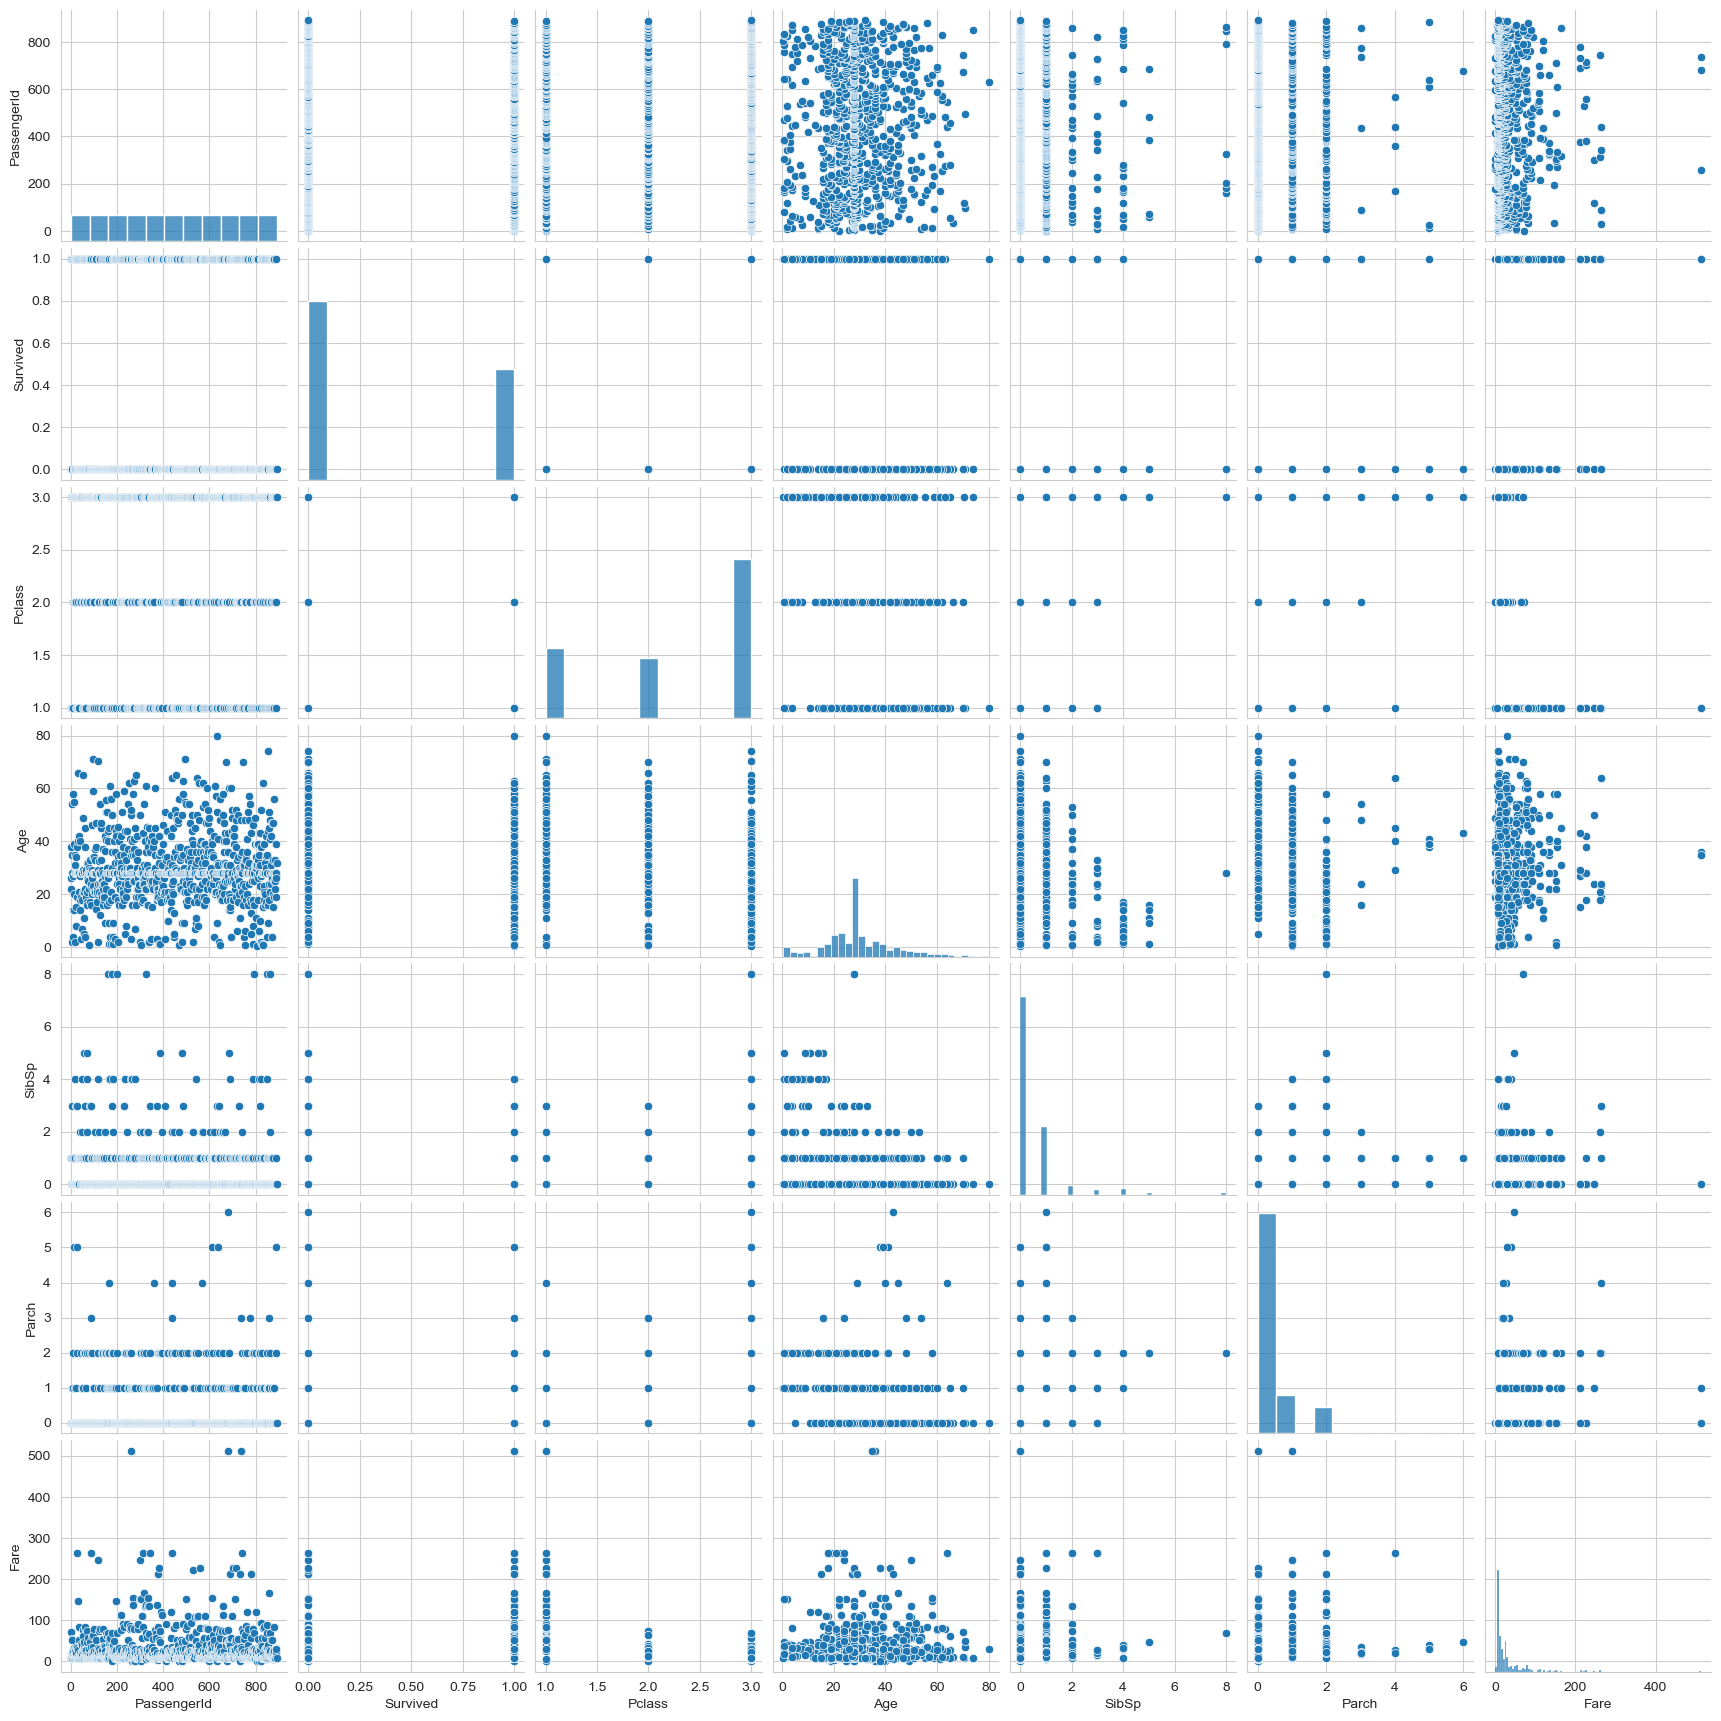

In [19]:
sns.pairplot(df)
plt.show()

# Observation
- The pairplot helps visualize relationships between numerical features.
- Most variables do not exhibit strong linear relationships.
- It also helps identify clusters, trends, and potential outliers.

# ScatterPlot

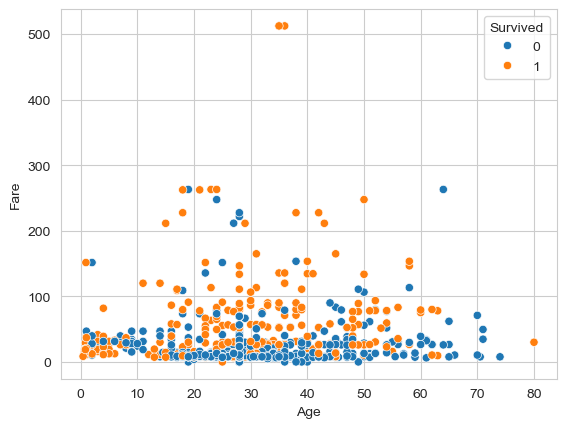

In [20]:
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.show()

# Observation
- The scatter plot shows the relationship between **Age** and **Fare**.
- There is no strong linear relationship between these two variables.
- Higher fare values are concentrated among a smaller number of passengers.

# CountPlot

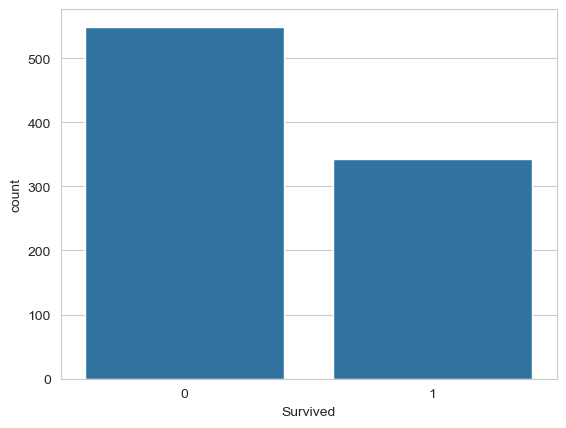

In [21]:
sns.countplot(x="Survived", data=df)
plt.show()

# Observation
- The number of passengers who did not survive is slightly higher than those who survived.
- The dataset contains both survivor and non-survivor records, making it suitable for survival analysis.

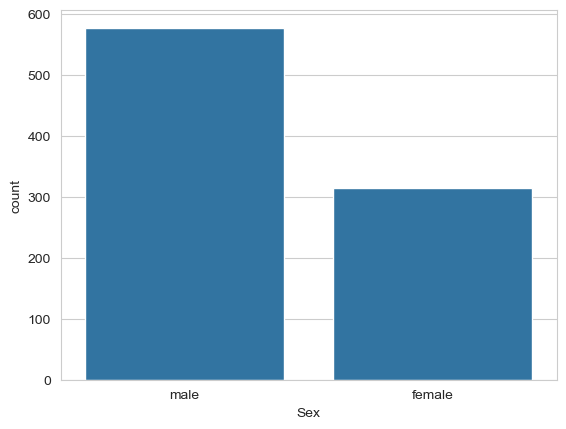

In [22]:
sns.countplot(x="Sex", data=df)
plt.show()

# Observation
- The dataset contains more **male** passengers than **female** passengers.
- Gender distribution is not perfectly balanced.

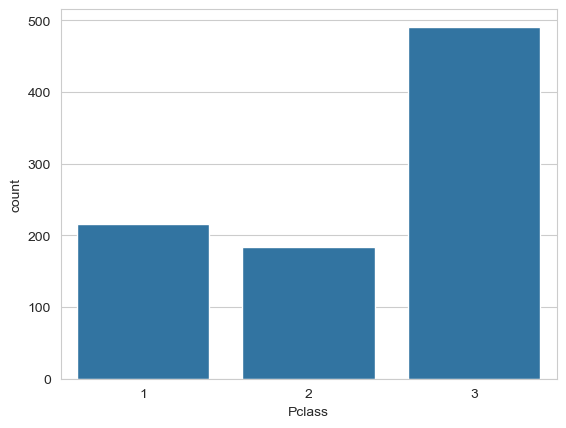

In [23]:
sns.countplot(x="Pclass", data=df)
plt.show()

# Observation
- Most passengers belonged to the **Third Class (Pclass 3)**.
- First-class passengers were fewer compared to second and third class.

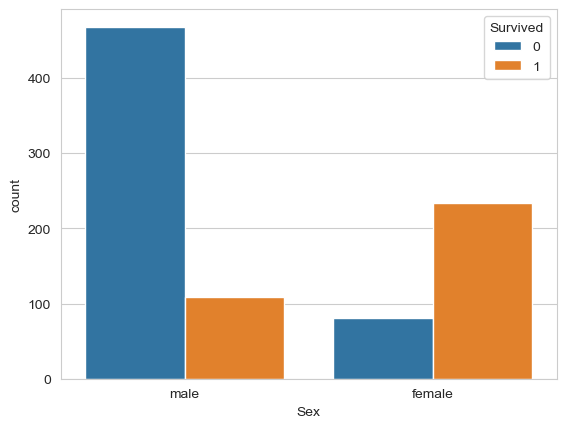

In [24]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

# Observation
- Female passengers had a much higher survival rate than male passengers.
- This suggests that gender played an important role in survival during the disaster.

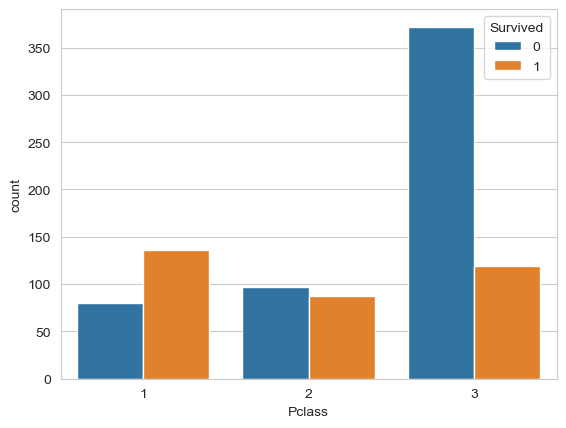

In [25]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

# Observation
- First-class passengers had the highest survival rate.
- Third-class passengers experienced the lowest survival rate.
- Passenger class appears to have a significant impact on survival.

# Summary of Findings
- Missing values in Age and Embarked were handled, and the Cabin column was removed due to a high number of missing values.
- Most passengers were between 20 and 40 years old.
- Fare distribution is positively skewed and contains several outliers.
- Female passengers had a higher survival rate than male passengers.
- First-class passengers had a better chance of survival than passengers in lower classes.
- Correlation analysis showed that Fare has a weak positive relationship with survival, while Passenger Class has a negative relationship with survival.
- Overall, EDA helped identify important trends and relationships within the Titanic dataset.